Metric components (equatorial):
g_tt(r)   = 2*M/r - 1
g_rr(r)   = 1/(-2*M/r + 1)
g_phph(r) = r**2
g_tt * g_rr = -1

General radial equation R_timelike(r) = (dr/dλ)^2:
(E**2*r**3 + (L**2 + r**2)*(2*M - r))/r**3

General radial equation R_null(r) = (dr/dλ)^2:
(E**2*r**3 + L**2*(2*M - r))/r**3

Timelike effective potential V_eff (assuming g_tt*g_rr=-1):
-(L**2 + r**2)*(2*M - r)/r**3

Null effective potential V_eff_null (assuming g_tt*g_rr=-1):
L**2*(-2*M + r)/r**3

Circular orbit L^2(r):
M*r**2/(-3*M + r)

Circular orbit E^2(r):
-(2*M - r)**2/(r*(3*M - r))

ISCO radius candidates (symbolic):
[2*M, 6*M]

Simplified ISCO candidates:
[2*M, 6*M]

Photon sphere radius candidates (symbolic):
[3*M]

Simplified photon sphere candidates:
[3*M]

Critical impact parameter b_crit (shadow radius) =
3*sqrt(3)*M

Numeric example: b_crit (M=1) = 5.196152422706632


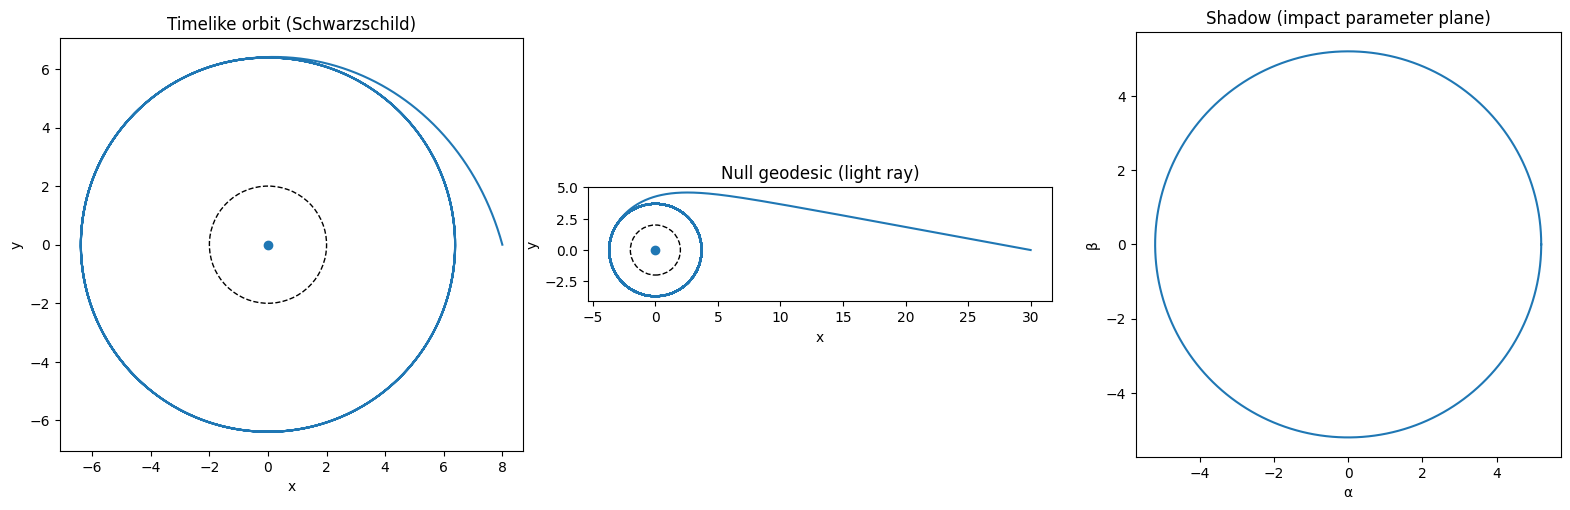


SUMMARY (Schwarzschild example):
ISCO radius r_ISCO = [2, 6]
Photon sphere r_ph = [3]
Shadow radius b_crit (M=1) = 5.196152422706632


In [ ]:
"""
General geodesics & effective potentials for static spherically symmetric metrics.

- Signature (-,+,+,+), units G = c = 1
- Metric form (equatorial plane θ = π/2):

    ds^2 = g_tt(r) dt^2 + g_rr(r) dr^2 + g_phph(r) dφ^2

User can replace g_tt, g_rr, g_thth, g_phph with any spherically symmetric metric.
Schwarzschild is used as an example.
"""

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Symbolic setup
# ============================================================

# Symbols
r, theta = sp.symbols('r theta', real=True)
M = sp.symbols('M', positive=True, real=True)   # Mass parameter
E, L = sp.symbols('E L', real=True)            # Conserved energy & angular momentum

# ------------------------------------------------------------
# USER SECTION: define metric components here
# ------------------------------------------------------------
# Example: Schwarzschild metric
#   ds^2 = -(1-2M/r) dt^2 + (1-2M/r)^(-1) dr^2 + r^2 dθ^2 + r^2 sin^2θ dφ^2

g_tt   = -(1 - 2*M/r)
g_rr   = 1/(1 - 2*M/r)
g_thth = r**2
g_phph = r**2 * sp.sin(theta)**2

# Equatorial plane θ = π/2
g_phph_eq = g_phph.subs(theta, sp.pi/2)

# Check the common condition g_tt * g_rr = -1 (true for Schwarzschild)
product_gtt_grr = sp.simplify(g_tt * g_rr)

print("Metric components (equatorial):")
print("g_tt(r)   =", g_tt)
print("g_rr(r)   =", g_rr)
print("g_phph(r) =", g_phph_eq)
print("g_tt * g_rr =", product_gtt_grr)

# ============================================================
# 2. Conserved quantities from Killing vectors
# ============================================================

"""
For a static, spherically symmetric metric:

- Stationarity Killing vector: ξ^(t) = ∂_t
  -> conserved E = -p_t = -g_tt u^t

- Axial Killing vector: ξ^(φ) = ∂_φ
  -> conserved L =  p_φ =  g_φφ u^φ

We will use E and L directly as constants in the radial equation.
"""

# ============================================================
# 3. Effective potentials & radial equations
# ============================================================

"""
We consider motion in equatorial plane θ = π/2, u^θ = 0.

Normalization:
    g_tt (u^t)^2 + g_rr (u^r)^2 + g_phph (u^φ)^2 = -κ

κ = 1 for timelike geodesics (massive particle, u^μ u_μ = -1)
κ = 0 for null geodesics (photon,  u^μ u_μ =  0)

Using:
    E = -g_tt u^t  -> u^t = -E/g_tt
    L =  g_phph u^φ -> u^φ = L/g_phph

Plug in to get radial equation (u^r = dr/dλ):

    (dr/dλ)^2 = R(r; E, L, κ)
"""

kappa_timelike = 1
kappa_null     = 0

# General radial functions R(r) = (dr/dλ)^2
R_timelike_general = -E**2/(g_tt * g_rr) - (L**2/g_phph_eq + kappa_timelike)/g_rr
R_null_general     = -E**2/(g_tt * g_rr) - (L**2/g_phph_eq + kappa_null)/g_rr

R_timelike_general_simpl = sp.simplify(R_timelike_general)
R_null_general_simpl     = sp.simplify(R_null_general)

print("\nGeneral radial equation R_timelike(r) = (dr/dλ)^2:")
print(R_timelike_general_simpl)

print("\nGeneral radial equation R_null(r) = (dr/dλ)^2:")
print(R_null_general_simpl)

# ------------------------------------------------------------
# Effective potentials in the special case g_tt * g_rr = -1
# ------------------------------------------------------------

"""
If g_tt * g_rr = -1 (true for Schwarzschild and many standard BH metrics),
we can rewrite the timelike and null equations as:

    (dr/dτ)^2 + V_eff_timelike(r) = E^2
    (dr/dλ)^2 + V_eff_null(r)     = E^2

with

    V_eff_timelike(r) = (-g_tt) * (1 + L^2 / g_phph)
    V_eff_null(r)     = (-g_tt) * (L^2 / g_phph)
"""

if sp.simplify(product_gtt_grr + 1) == 0:
    V_eff_timelike = sp.simplify((-g_tt) * (1 + L**2 / g_phph_eq))
    V_eff_null     = sp.simplify((-g_tt) * (L**2 / g_phph_eq))
else:
    # Generic fallback: define V_eff = E^2 - R
    V_eff_timelike = sp.simplify(E**2 - R_timelike_general_simpl)
    V_eff_null     = sp.simplify(E**2 - R_null_general_simpl)

print("\nTimelike effective potential V_eff (assuming g_tt*g_rr=-1):")
print(V_eff_timelike)

print("\nNull effective potential V_eff_null (assuming g_tt*g_rr=-1):")
print(V_eff_null)

# ============================================================
# 4. Circular orbits & ISCO for Schwarzschild
# ============================================================

"""
For timelike circular orbits (constant r):

    (dr/dτ)^2 = 0        -> E^2 = V_eff(r)
    dV_eff/dr = 0        -> extremum (circular orbit)
    d^2 V_eff / dr^2 > 0 -> stable (if equality -> ISCO)

We solve symbolically for Schwarzschild.
"""

dV_dr = sp.diff(V_eff_timelike, r)

# Solve dV/dr = 0 for L^2 = L2(r)
L2_of_r = sp.simplify(sp.solve(sp.Eq(dV_dr, 0), L**2)[0])

# Substitute into V_eff to get E^2(r) for circular orbits
E2_of_r = sp.simplify(V_eff_timelike.subs(L**2, L2_of_r))

# ISCO condition: d^2V_eff/dr^2 = 0 with L^2(r) substituted
d2V_dr2 = sp.diff(V_eff_timelike.subs(L**2, L2_of_r), r)
r_isco_solutions = sp.solve(sp.Eq(d2V_dr2, 0), r)

print("\nCircular orbit L^2(r):")
print(L2_of_r)

print("\nCircular orbit E^2(r):")
print(E2_of_r)

print("\nISCO radius candidates (symbolic):")
print(r_isco_solutions)

# For Schwarzschild, physical ISCO is r = 6 M
r_isco_simpl = [sp.simplify(sol) for sol in r_isco_solutions]
print("\nSimplified ISCO candidates:")
print(r_isco_simpl)

# ============================================================
# 5. Photon sphere & shadow radius
# ============================================================

"""
For null geodesics, define impact parameter b = L/E.

From radial equation with κ=0, circular photon orbits satisfy:

    R_null(r) = 0     and   dR_null/dr = 0

Equivalently, one finds:
    b^2(r) = - g_phph(r) / g_tt(r)
and the photon sphere radius r_ph solves:
    d/dr [ -g_phph/g_tt ] = 0.

The BH "shadow" for a static, spherically symmetric spacetime is a circle
of radius b_crit = b(r_ph) in the observer's sky.
"""

b2 = -g_phph_eq / g_tt
db2_dr = sp.diff(b2, r)
r_ph_solutions = sp.solve(sp.Eq(db2_dr, 0), r)

print("\nPhoton sphere radius candidates (symbolic):")
print(r_ph_solutions)

# For Schwarzschild, physical photon sphere is r = 3M
r_ph_simpl = [sp.simplify(sol) for sol in r_ph_solutions]
print("\nSimplified photon sphere candidates:")
print(r_ph_simpl)

# Take the physical (positive) solution and compute b_crit
r_ph = r_ph_simpl[0]   # for Schwarzschild this is 3*M
b_crit_sq = sp.simplify(b2.subs(r, r_ph))
b_crit = sp.simplify(sp.sqrt(b_crit_sq))

print("\nCritical impact parameter b_crit (shadow radius) =")
print(b_crit)   # For Schwarzschild -> 3*sqrt(3)*M

# ============================================================
# 6. Numeric helpers: lambdify
# ============================================================

# Choose a numeric mass scale, e.g. M = 1
M_val = 1.0

# Lambdify metric components & potentials
g_tt_num   = sp.lambdify((r, M), g_tt, 'numpy')
g_rr_num   = sp.lambdify((r, M), g_rr, 'numpy')
g_phph_num = sp.lambdify((r, M), g_phph_eq, 'numpy')

V_timelike_num = sp.lambdify((r, L, M), V_eff_timelike, 'numpy')
V_null_num     = sp.lambdify((r, L, M), V_eff_null, 'numpy')

b_crit_num = float(sp.N(b_crit.subs(M, M_val)))

print("\nNumeric example: b_crit (M=1) =", b_crit_num)

# ============================================================
# 7. Example timelike and null orbits (shape plots)
# ============================================================

"""
We now integrate the radial equation numerically to obtain r(φ)
for a timelike and a null geodesic in Schwarzschild, and then
plot their shapes in polar coordinates.

We use the generic radial equation:

    (dr/dλ)^2 = -E^2 / (g_tt g_rr) - (L^2 / g_phph + κ) / g_rr

and:

    dφ/dλ = L / g_phph
"""

def radial_R(r_val, E_val, L_val, kind="timelike"):
    gtt = g_tt_num(r_val, M_val)
    grr = g_rr_num(r_val, M_val)
    gph = g_phph_num(r_val, M_val)
    kappa = 1.0 if kind == "timelike" else 0.0
    return -E_val**2/(gtt*grr) - (L_val**2/gph + kappa)/grr

def rhs_geodesic(lam, y, E_val, L_val, kind="timelike"):
    """
    y = [r, φ]; return dy/dλ
    """
    r_val, phi_val = y
    gph = g_phph_num(r_val, M_val)
    R_val = radial_R(r_val, E_val, L_val, kind)

    # If R becomes negative (turning point or outside allowed region),
    # set dr/dλ = 0 to avoid NaNs.
    if R_val < 0:
        dr_dlam = 0.0
    else:
        # Infalling (choose minus sign) or outgoing (+ sign)
        dr_dlam = -np.sqrt(R_val)

    dphi_dlam = L_val / gph
    return np.array([dr_dlam, dphi_dlam])

def integrate_orbit(r0, phi0, E_val, L_val, kind="timelike",
                    lam_max=200.0, n_steps=5000):
    """
    Simple RK4 integrator for r(λ), φ(λ).
    """
    lam_vals = np.linspace(0.0, lam_max, n_steps)
    dl = lam_vals[1] - lam_vals[0]

    r_vals = np.zeros(n_steps)
    phi_vals = np.zeros(n_steps)
    r_vals[0] = r0
    phi_vals[0] = phi0

    for i in range(n_steps - 1):
        lam = lam_vals[i]
        y  = np.array([r_vals[i], phi_vals[i]])

        k1 = rhs_geodesic(lam,         y,             E_val, L_val, kind)
        k2 = rhs_geodesic(lam + dl/2., y + dl*k1/2.,  E_val, L_val, kind)
        k3 = rhs_geodesic(lam + dl/2., y + dl*k2/2.,  E_val, L_val, kind)
        k4 = rhs_geodesic(lam + dl,    y + dl*k3,     E_val, L_val, kind)

        y_next = y + (dl/6.)*(k1 + 2*k2 + 2*k3 + k4)

        r_vals[i+1]   = y_next[0]
        phi_vals[i+1] = y_next[1]

        # Stop if we hit the horizon or go too far
        if r_vals[i+1] < 2.1*M_val or r_vals[i+1] > 100*M_val:
            r_vals = r_vals[:i+2]
            phi_vals = phi_vals[:i+2]
            lam_vals = lam_vals[:i+2]
            break

    return lam_vals, r_vals, phi_vals

# ------------------------------------------------------------
# Example: bound timelike orbit
# ------------------------------------------------------------

# Choose L so that orbits exist outside ISCO; say L = 4M
L_timelike = 4.0 * M_val
# Choose a radius slightly larger than ISCO for starting point
r_start_timelike = 8.0 * M_val

# For bound-ish orbit, choose E slightly above minimum of V_eff around r_start
V_min_guess = V_timelike_num(r_start_timelike, L_timelike, M_val)
E_timelike = np.sqrt(V_min_guess * 1.02)  # slightly above

lam_t, r_t, phi_t = integrate_orbit(r_start_timelike, 0.0,
                                    E_timelike, L_timelike, kind="timelike",
                                    lam_max=300.0, n_steps=6000)

# Convert to Cartesian for plotting orbit shape
x_t = r_t * np.cos(phi_t)
y_t = r_t * np.sin(phi_t)

# ------------------------------------------------------------
# Example: null orbit (light ray) near the photon sphere
# ------------------------------------------------------------

# Use impact parameter slightly above b_crit to get a scattered photon
b_null = 1.05 * b_crit_num
E_null = 1.0
L_null = b_null * E_null

r_start_null = 30.0 * M_val  # far away
V_null_start = V_null_num(r_start_null, L_null, M_val)
# For null geodesic, E^2 can be chosen to match region where R>0
# Use E_null = 1 already.

lam_n, r_n, phi_n = integrate_orbit(r_start_null, 0.0,
                                    E_null, L_null, kind="null",
                                    lam_max=500.0, n_steps=8000)

x_n = r_n * np.cos(phi_n)
y_n = r_n * np.sin(phi_n)

# ============================================================
# 8. Plotting: timelike orbit, null orbit, and shadow
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# 8.1 Timelike orbit
axs[0].plot(x_t, y_t)
axs[0].scatter(0, 0, marker='o')  # central mass
axs[0].set_aspect('equal', 'box')
axs[0].set_title("Timelike orbit (Schwarzschild)")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")

# Horizon circle for reference
r_horizon = 2.0 * M_val
circle_h = plt.Circle((0, 0), r_horizon, fill=False, linestyle='--')
axs[0].add_artist(circle_h)

# 8.2 Null orbit (light ray)
axs[1].plot(x_n, y_n)
axs[1].scatter(0, 0, marker='o')
axs[1].set_aspect('equal', 'box')
axs[1].set_title("Null geodesic (light ray)")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")

circle_h2 = plt.Circle((0, 0), r_horizon, fill=False, linestyle='--')
axs[1].add_artist(circle_h2)

# 8.3 Shadow shape (impact parameter plane)
alpha = np.linspace(0, 2*np.pi, 400)
shadow_x = b_crit_num * np.cos(alpha)
shadow_y = b_crit_num * np.sin(alpha)

axs[2].plot(shadow_x, shadow_y)
axs[2].set_aspect('equal', 'box')
axs[2].set_title("Shadow (impact parameter plane)")
axs[2].set_xlabel("α")
axs[2].set_ylabel("β")

plt.tight_layout()
plt.show()

# ============================================================
# 9. Summary printout
# ============================================================

print("\nSUMMARY (Schwarzschild example):")
print("ISCO radius r_ISCO =", [sp.simplify(sol.subs(M, 1)) for sol in r_isco_simpl])
print("Photon sphere r_ph =", [sp.simplify(sol.subs(M, 1)) for sol in r_ph_simpl])
print("Shadow radius b_crit (M=1) =", b_crit_num)
